In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path 

In [5]:
# NYC TLC publishes monthly parquet files. Start small: one month.
DATA_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"

# Figure out where data/raw/ lives, relative to this notebook
RAW_DIR = Path.cwd().parent / "data" / "raw"
RAW_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_FILE = RAW_DIR / "yellow_tripdata_2023-01.parquet"

# Only download if we don't already have it
if not LOCAL_FILE.exists():
    import urllib.request
    print(f"Downloading to {LOCAL_FILE} ...")
    urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)
    print("Done.")
else:
    print(f"Already have {LOCAL_FILE}")

print(f"File size: {LOCAL_FILE.stat().st_size / 1e6:.1f} MB")

Already have /Users/vansh/Project AI/ridehail-demand/data/raw/yellow_tripdata_2023-01.parquet
File size: 47.7 MB


In [6]:
df = pd.read_parquet(LOCAL_FILE)

print(f"Shape: {df.shape}")        # (rows, columns)
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (3066766, 19)
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.3,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.9,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.9,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.1,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.4,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

In [ ]:
print("Earliest pickup:", df["tpep_pickup_datetime"].min()) #df[column] pulls out one columns asa series
print("Latest pickup:  ", df["tpep_pickup_datetime"].max())

Earliest pickup: 2008-12-31 23:01:42
Latest pickup:   2023-02-01 00:56:53


In [13]:
before = len(df)

mask = (df["tpep_pickup_datetime"] >= "2023-01-01") & (df["tpep_pickup_datetime"] < "2023-02-01")
df = df[mask].copy()

after = len(df)

print(f"dropped like {before-after} rows")
print(f"kept {after} rows")


dropped like 0 rows
kept 3066718 rows


In [ ]:
#Round of each pickup time to the nearest hour and put it in a new column called pickup_hour
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")

#group by hour, zone, count trips and put it in demand
demand = (
            df.groupby(["pickup_hour", "PULocationID"]).size().reset_index(name="demand")
)

print("demand table shape", demand.shape)
demand.head(10)


demand table shape (71491, 3)


,pickup_hour,PULocationID,demand
0,2023-01-01,4,19
1,2023-01-01,7,3
2,2023-01-01,12,1
3,2023-01-01,13,14
4,2023-01-01,24,20
5,2023-01-01,25,4
6,2023-01-01,33,12
7,2023-01-01,36,6
8,2023-01-01,37,1
9,2023-01-01,39,1


In [43]:
demand.head(120)

,pickup_hour,PULocationID,demand
0,2023-01-01 00:00:00,4,19
1,2023-01-01 00:00:00,7,3
2,2023-01-01 00:00:00,12,1
3,2023-01-01 00:00:00,13,14
4,2023-01-01 00:00:00,24,20
...,...,...,...
115,2023-01-01 01:00:00,16,1
116,2023-01-01 01:00:00,17,7
117,2023-01-01 01:00:00,24,12
118,2023-01-01 01:00:00,25,12


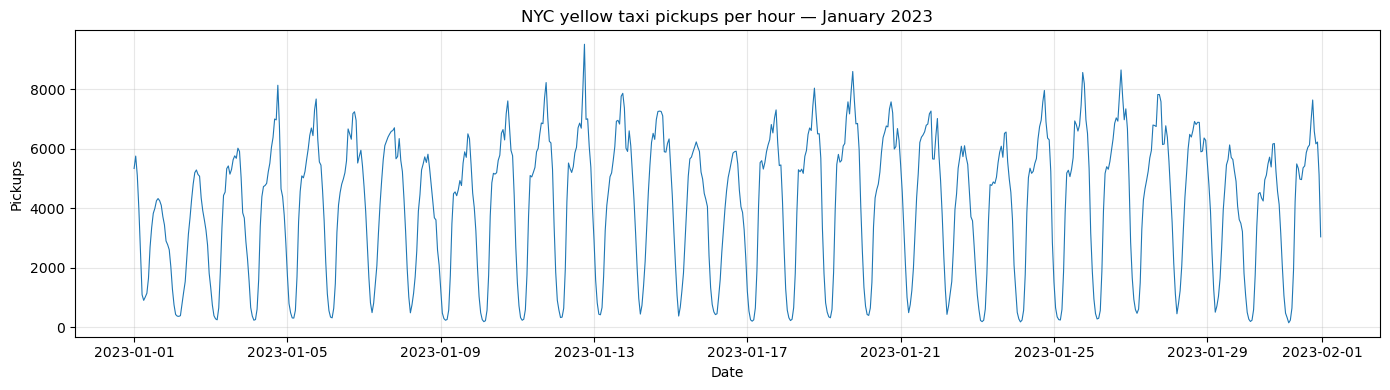

In [44]:
citywide = demand.groupby("pickup_hour")["demand"].sum()

plt.figure(figsize=(14, 4))
plt.plot(citywide.index, citywide.values, linewidth=0.8)
plt.title("NYC yellow taxi pickups per hour — January 2023")
plt.xlabel("Date")
plt.ylabel("Pickups")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()